# Lab 8 — Information Theory, Block Codes and Convolutional Codes

**Companion to Chapter 8.** Objectives:

1. Compute Shannon capacity, the Shannon limit, and constellation-constrained
   capacity for QPSK/16-QAM/64-QAM.
2. Measure the coding gain of Hamming(7,4) and of the K=7 (133,171) convolutional
   code with hard- and soft-decision Viterbi decoding.
3. Understand puncturing: one mother code, many rates.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(8)

## 1. Capacity and the Shannon limit
For bandwidth-limited AWGN, $C = \log_2(1 + \mathrm{SNR})$ bits/s/Hz. Rewriting at
spectral efficiency $\eta$: reliable communication requires
$E_b/N_0 \ge (2^\eta - 1)/\eta$, which tends to $\ln 2 = -1.59$ dB as $\eta \to 0$.
Practical constellations cannot reach the Gaussian-input curve; their
**constrained capacity** (mutual information with uniform inputs) is estimated
below by Monte Carlo: $I = k - E\left[\log_2 \frac{\sum_a e^{-|y-a|^2/N_0}}{e^{-|y-x|^2/N_0}}\right]$.

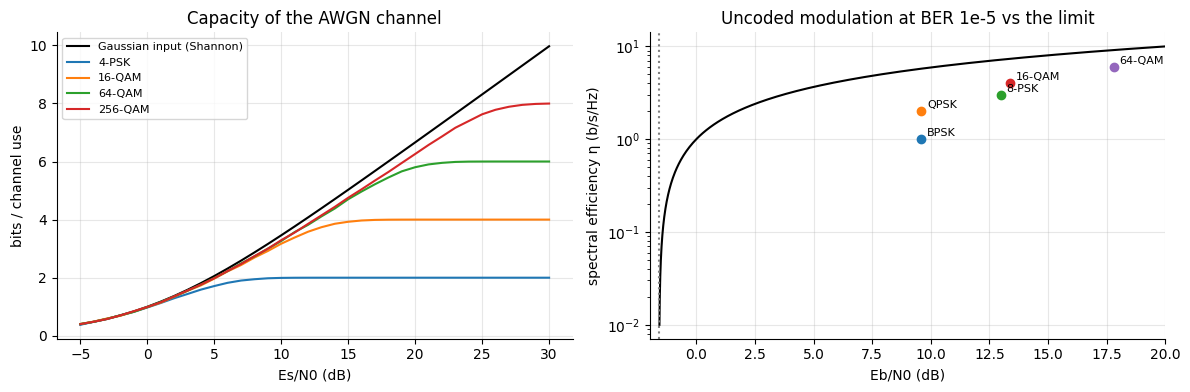

In [3]:
def constrained_capacity(c, esn0_db, n=20000):
    idx = rng.integers(0, c.M, n)
    x = c.points[idx]
    y, n0 = cl.awgn_esn0(x, esn0_db, rng=rng, es=1.0)
    d = -np.abs(y[:, None] - c.points[None, :]) ** 2 / n0
    from scipy.special import logsumexp
    return c.k - np.mean((logsumexp(d, axis=1) - d[np.arange(n), idx]) / np.log(2))

snr = np.arange(-5, 31, 1.0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(snr, np.log2(1 + 10 ** (snr / 10)), "k", label="Gaussian input (Shannon)")
for nm in ["qpsk", "16qam", "64qam", "256qam"]:
    c = cl.get_constellation(nm)
    ax[0].plot(snr, [constrained_capacity(c, s) for s in snr], label=c.name)
ax[0].set_xlabel("Es/N0 (dB)"); ax[0].set_ylabel("bits / channel use"); ax[0].legend(fontsize=8)
ax[0].set_title("Capacity of the AWGN channel")
eta = np.logspace(-2, np.log10(10), 200)
ax[1].semilogy(10 * np.log10((2 ** eta - 1) / eta), eta, "k", label="Shannon bound")
ax[1].axvline(-1.59, color="gray", ls=":")
# uncoded operating points at BER 1e-5
pts = {"BPSK": (9.6, 1), "QPSK": (9.6, 2), "8-PSK": (13.0, 3), "16-QAM": (13.4, 4), "64-QAM": (17.8, 6)}
for nm, (e, k) in pts.items():
    ax[1].plot(e, k, "o"); ax[1].annotate(nm, (e, k), xytext=(4, 2), textcoords="offset points", fontsize=8)
ax[1].set_xlabel("Eb/N0 (dB)"); ax[1].set_ylabel("spectral efficiency η (b/s/Hz)")
ax[1].set_title("Uncoded modulation at BER 1e-5 vs the limit"); ax[1].set_xlim(-2, 20)
plt.tight_layout(); plt.show()

The horizontal gap between each dot and the bound (≈ 9–11 dB) is the coding gain
available. Chapters 8 and 9 are about spending complexity to close it.

## 2. A first block code: Hamming (7,4)
$d_{\min} = 3$, corrects one error per block, rate 4/7. Compare at equal $E_b/N_0$:
coded bits get $E_c = R\,E_b$, so each coded bit is noisier.

In [6]:
def bpsk_awgn(c_bits, ebn0_db, rate):
    sigma = np.sqrt(1 / (2 * rate * 10 ** (ebn0_db / 10)))
    y = (1 - 2 * c_bits.astype(float)) + sigma * rng.standard_normal(len(c_bits))
    return y, sigma

eb = np.arange(0, 11, 1.0)
u = cl.random_bits(4 * 50000, rng)
ber_h = []
for e in eb:
    y, _ = bpsk_awgn(cl.hamming74_encode(u), e, 4 / 7)
    ber_h.append(np.mean(cl.hamming74_decode((y < 0).astype(np.int8)) != u))

## 3. Convolutional codes and the Viterbi algorithm
The K=7, rate-1/2 code with generators (133, 171)₈ has free distance 10 and is used
in 802.11a/g/n, DVB-S and deep-space links. Viterbi decoding finds the ML path
through a 64-state trellis. Soft decisions (LLRs) gain about 2 dB over hard
decisions, a lesson that carries to every modern decoder.

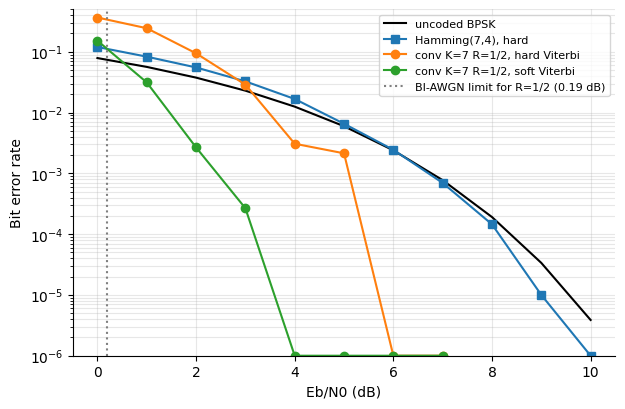

In [8]:
cc = cl.ConvCode()
def ber_conv(e, soft=True, frames=15, n=1000):
    errs = 0
    for _ in range(frames):
        u = cl.random_bits(n, rng)
        y, sigma = bpsk_awgn(cc.encode(u), e, cc.rate)
        llr = 2 * y / sigma ** 2 if soft else np.sign(y)
        errs += np.sum(cc.decode(llr) != u)
    return errs / (frames * n)

eb2 = np.arange(0, 7.5, 1.0)
ber_soft = [ber_conv(e, True) for e in eb2]
ber_hard = [ber_conv(e, False) for e in eb2]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(eb, cl.ber_bpsk(eb), "k", label="uncoded BPSK")
ax.semilogy(eb, np.maximum(ber_h, 1e-6), "s-", label="Hamming(7,4), hard")
ax.semilogy(eb2, np.maximum(ber_hard, 1e-6), "o-", label="conv K=7 R=1/2, hard Viterbi")
ax.semilogy(eb2, np.maximum(ber_soft, 1e-6), "o-", label="conv K=7 R=1/2, soft Viterbi")
ax.axvline(0.19, color="gray", ls=":", label="BI-AWGN limit for R=1/2 (0.19 dB)")
cl.ber_axes(ax); ax.set_ylim(1e-6, 0.5); ax.legend(fontsize=8); plt.show()

## 4. Puncturing
Deleting coded bits in a fixed pattern raises the rate without a new decoder;
the Viterbi decoder simply treats deleted positions as LLR = 0 (erasures).
802.11a obtains rate 3/4 from the rate-1/2 mother code with pattern
`[1 1 0 / 1 0 1]` over three input bits.

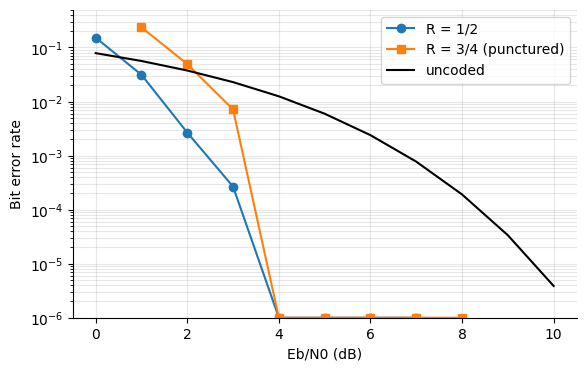

In [10]:
PAT34 = np.array([1, 1, 1, 0, 0, 1], dtype=bool)   # (A1 B1 A2 B2 A3 B3) keep mask

def puncture(c, pat):
    reps = int(np.ceil(len(c) / len(pat)))
    m = np.tile(pat, reps)[:len(c)]
    return c[m], m

def depuncture(llr, m):
    out = np.zeros(len(m)); out[m] = llr; return out

def ber_punct(e, frames=15, n=999):
    errs = 0
    for _ in range(frames):
        u = cl.random_bits(n, rng)
        cbits, m = puncture(cc.encode(u), PAT34)
        y, sigma = bpsk_awgn(cbits, e, 3 / 4)
        errs += np.sum(cc.decode(depuncture(2 * y / sigma ** 2, m)) != u)
    return errs / (frames * n)

eb3 = np.arange(1, 8.5, 1.0)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(eb2, np.maximum(ber_soft, 1e-6), "o-", label="R = 1/2")
ax.semilogy(eb3, np.maximum([ber_punct(e) for e in eb3], 1e-6), "s-", label="R = 3/4 (punctured)")
ax.semilogy(eb, cl.ber_bpsk(eb), "k", label="uncoded")
cl.ber_axes(ax); ax.set_ylim(1e-6, 0.5); ax.legend(); plt.show()

### Interactive: watch the decoder fix a noisy frame
Top: which coded bits arrived with the wrong sign. Bottom: residual errors after
Viterbi decoding. Errors after decoding come in bursts, a property that matters
when a convolutional code is concatenated with an outer code.

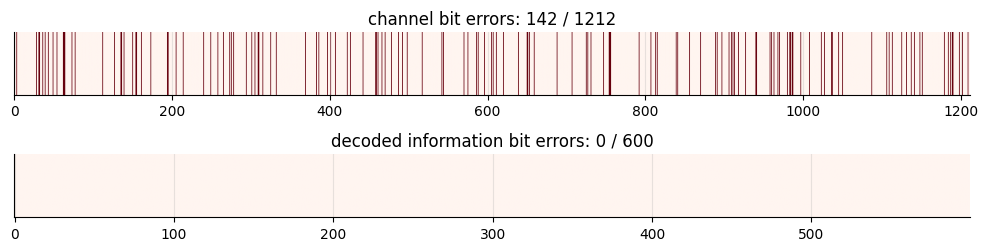

In [12]:
def frame_view(ebn0_db=2.0, decisions="soft"):
    u = cl.random_bits(600, rng)
    c = cc.encode(u)
    y, sigma = bpsk_awgn(c, ebn0_db, 0.5)
    raw = (y < 0) != c
    uh = cc.decode(2 * y / sigma ** 2 if decisions == "soft" else np.sign(y))
    fig, ax = plt.subplots(2, 1, figsize=(10, 2.6), sharex=False)
    ax[0].imshow(raw[None, :], aspect="auto", cmap="Reds"); ax[0].set_yticks([])
    ax[0].set_title(f"channel bit errors: {raw.sum()} / {len(c)}")
    ax[1].imshow((uh != u)[None, :], aspect="auto", cmap="Reds"); ax[1].set_yticks([])
    ax[1].set_title(f"decoded information bit errors: {(uh != u).sum()} / {len(u)}")
    plt.tight_layout(); plt.show()

interact(frame_view, ebn0_db=FloatSlider(value=2.0, min=-1, max=8, step=0.25),
         decisions=Dropdown(options=["soft", "hard"]));

## Exercises
1. **(Warm-up)** Derive the Shannon limit $E_b/N_0 \to \ln 2$ as $\eta \to 0$.
2. **(Core)** Find the free distance of the (133,171) code by running the Viterbi
   decoder on the all-zeros codeword with a single large error pattern, or by a
   breadth-first search on the trellis. Compare with the union bound
   $P_b \lesssim \sum_d \beta_d Q(\sqrt{2 d R E_b/N_0})$.
3. **(Core)** Add a block interleaver and a Rayleigh fading channel (Lab 5). Show how
   much interleaving depth the code needs to recover diversity.
4. **(Stretch)** Implement the BCJR (MAP) decoder for a 4-state recursive systematic
   code and build a rate-1/3 parallel concatenated turbo code (the 3G/4G code).